# Medium-Term Trading Strategy Report
## Regime Detection with Integrated HMM-Hurst (4-Regime System)

**Strategy Overview:**
- **Regime Detection**: 2-state HMM (Low Vol / High Vol) + Fixed Hurst Thresholds → 4 regimes
  - Regime 0: Low Vol + Trending → Follow Momentum
  - Regime 1: Low Vol + Mean-Reverting → Fade / Mean Reversion
  - Regime 2: High Vol + Trending → Aggressive Short
  - Regime 3: High Vol + Random → Cash / Risk-Off
- **Market Behavior**: Hurst exponent with fixed thresholds (H > 0.55 trending, H < 0.45 mean-reverting)
- **Entry/Exit**: Momentum indicators (RSI, MACD, Moving Averages) adapted to each regime
- **Position Sizing**: Dynamic sizing based on regime characteristics

In [1]:
# Import libraries and strategy components
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import from strategy_core module
from strategy import (
    load_data, 
    create_market_index,
    RegimeDetector,
    MomentumIndicators,
    AdaptiveTradingStrategy,
    run_backtest,
    print_backtest_results,
    load_sector_mapping,
    BrinsonAttribution,
    run_sector_attribution,
    get_sector_regime_tilts
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Libraries and strategy components loaded successfully!")

Libraries and strategy components loaded successfully!


## 1. Data Loading and Exploration

In [2]:
# Load data from data_cn folder
data = load_data('data_cn')

print(f"Data loaded successfully!")
print(f"Trading days: {data['close'].shape[0]}")
print(f"Number of stocks: {data['close'].shape[1]}")
print(f"Date range: {data['close'].index[0].date()} to {data['close'].index[-1].date()}")
print(f"\nAvailable data files: {list(data.keys())}")

Data loaded successfully!
Trading days: 4859
Number of stocks: 915
Date range: 2006-01-04 to 2025-12-31

Available data files: ['close', 'high', 'low', 'open', 'adjusted', 'mktcap']


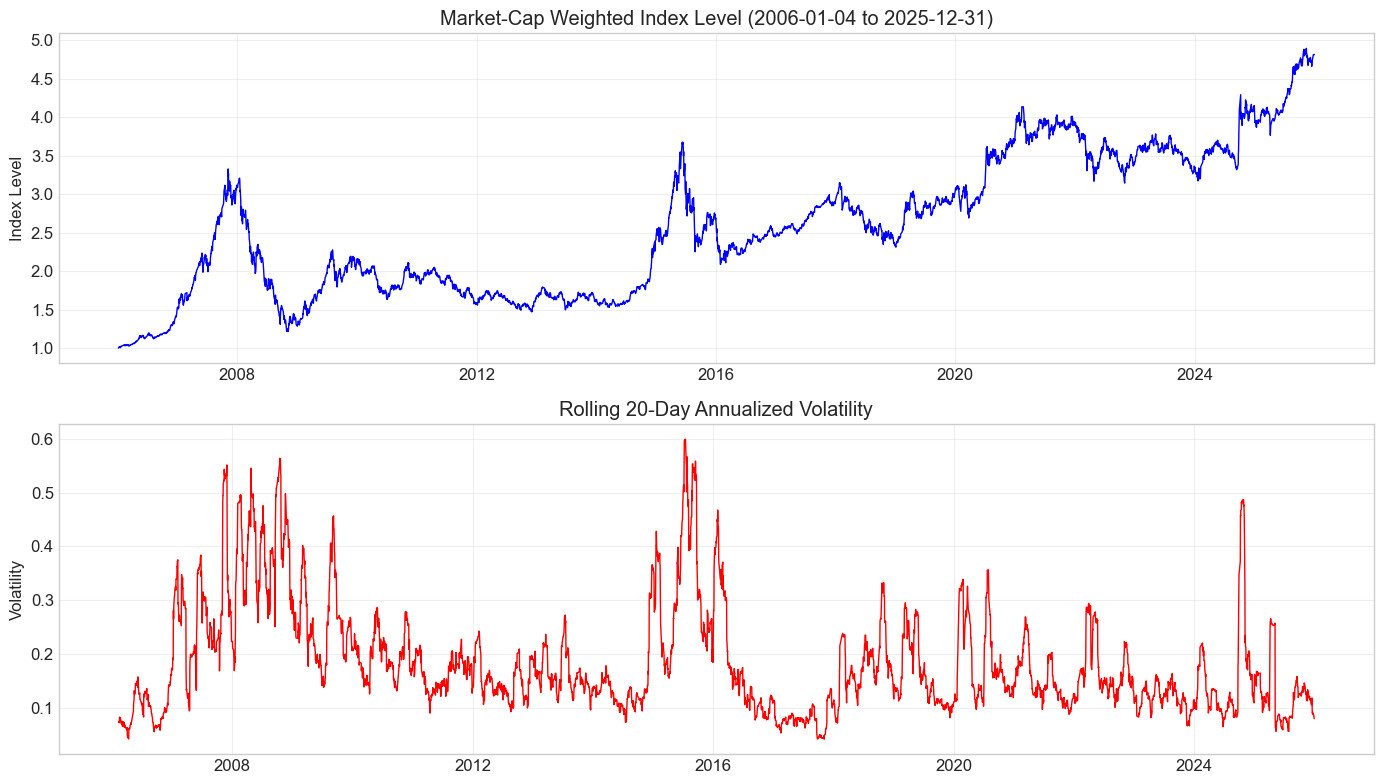


Index Statistics:
Total Return: 381.79%
Annualized Volatility: 20.96%


In [3]:
# Create market-cap weighted index
index_level, index_returns = create_market_index(data['adjusted'], data['mktcap'])

# Plot index and volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(index_level, color='blue', linewidth=1)
axes[0].set_title('Market-Cap Weighted Index Level (2006-01-04 to 2025-12-31)')
axes[0].set_ylabel('Index Level')
axes[0].grid(True, alpha=0.3)

rolling_vol = index_returns.rolling(20).std() * np.sqrt(252)
axes[1].plot(rolling_vol, color='red', linewidth=1)
axes[1].set_title('Rolling 20-Day Annualized Volatility')
axes[1].set_ylabel('Volatility')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nIndex Statistics:")
print(f"Total Return: {(index_level.iloc[-1] - 1):.2%}")
print(f"Annualized Volatility: {index_returns.std() * np.sqrt(252):.2%}")

## 2. Integrated HMM-Hurst Regime Detection

The strategy uses a **2-state Gaussian HMM** for volatility regime (Low Vol / High Vol), combined with **fixed Hurst exponent thresholds** to create 4 market conditions:

| HMM State | Hurst | Market Condition | Execution |
|-----------|-------|------------------|-----------|
| **State 0 (Low Vol)** | H > 0.55 | Steady, strong trend | Long: Follow momentum |
| **State 0 (Low Vol)** | H < 0.45 | Bound / mean-reverting | Fade: Trade against momentum |
| **State 1 (High Vol)** | H > 0.55 | Sustained market crash | Short: Aggressive short trend |
| **State 1 (High Vol)** | 0.45 ≤ H ≤ 0.55 | Erratic / random walk | Cash: Risk-off allocation |

- **Regime 0**: Low Vol + Trending (Follow Momentum)
- **Regime 1**: Low Vol + Mean-Reverting (Fade)
- **Regime 2**: High Vol + Trending (Aggressive Short)
- **Regime 3**: High Vol + Random/Uncertain (Cash/Risk-Off)

In [4]:
# Initialize and fit the 2-state HMM + Hurst threshold regime detector
regime_detector = RegimeDetector(n_regimes=2, lookback=252, hurst_window=60)
regimes, hurst_values = regime_detector.fit_predict(index_returns)

print("4-Regime Detection Results (2-state HMM + Hurst Thresholds):")
print(f"  Hurst Thresholds: lower={regime_detector.hurst_lower:.3f}, upper={regime_detector.hurst_upper:.3f}")
print()
print(f"  Regime 0 (Low Vol + Trending):   {(regimes == 0).sum()} days ({(regimes == 0).mean():.1%}) [Follow Momentum]")
print(f"  Regime 1 (Low Vol + Mean-Rev):   {(regimes == 1).sum()} days ({(regimes == 1).mean():.1%}) [Fade]")
print(f"  Regime 2 (High Vol + Trending):  {(regimes == 2).sum()} days ({(regimes == 2).mean():.1%}) [Aggressive Short]")
print(f"  Regime 3 (High Vol + Random):    {(regimes == 3).sum()} days ({(regimes == 3).mean():.1%}) [Cash/Risk-Off]")

print(f"\nHurst Exponent Statistics:")
hurst_clean = hurst_values.dropna()
print(f"  Mean: {hurst_clean.mean():.3f}")
print(f"  Std:  {hurst_clean.std():.3f}")
print(f"  Range: {hurst_clean.min():.3f} to {hurst_clean.max():.3f}")

4-Regime Detection Results (2-state HMM + Hurst Thresholds):
  Hurst Thresholds: lower=0.450, upper=0.550

  Regime 0 (Low Vol + Trending):   2990 days (61.5%) [Follow Momentum]
  Regime 1 (Low Vol + Mean-Rev):   56 days (1.2%) [Fade]
  Regime 2 (High Vol + Trending):  1474 days (30.3%) [Aggressive Short]
  Regime 3 (High Vol + Random):    279 days (5.7%) [Cash/Risk-Off]

Hurst Exponent Statistics:
  Mean: 0.666
  Std:  0.111
  Range: 0.342 to 1.000



Mean Hurst Exponent by Regime

Regime                                               Mean H      Std    Count        %
----------------------------------------------------------------------------------
Regime 0: Low Vol + Trending (Follow Momentum)        0.672    0.105     2990    61.5%
Regime 1: Low Vol + Mean-Rev (Fade)                   0.411    0.030       56     1.2%
Regime 2: High Vol + Trending (Aggressive Short)      0.696    0.095     1474    30.3%
Regime 3: High Vol + Random (Cash/Risk-Off)           0.503    0.040      279     5.7%


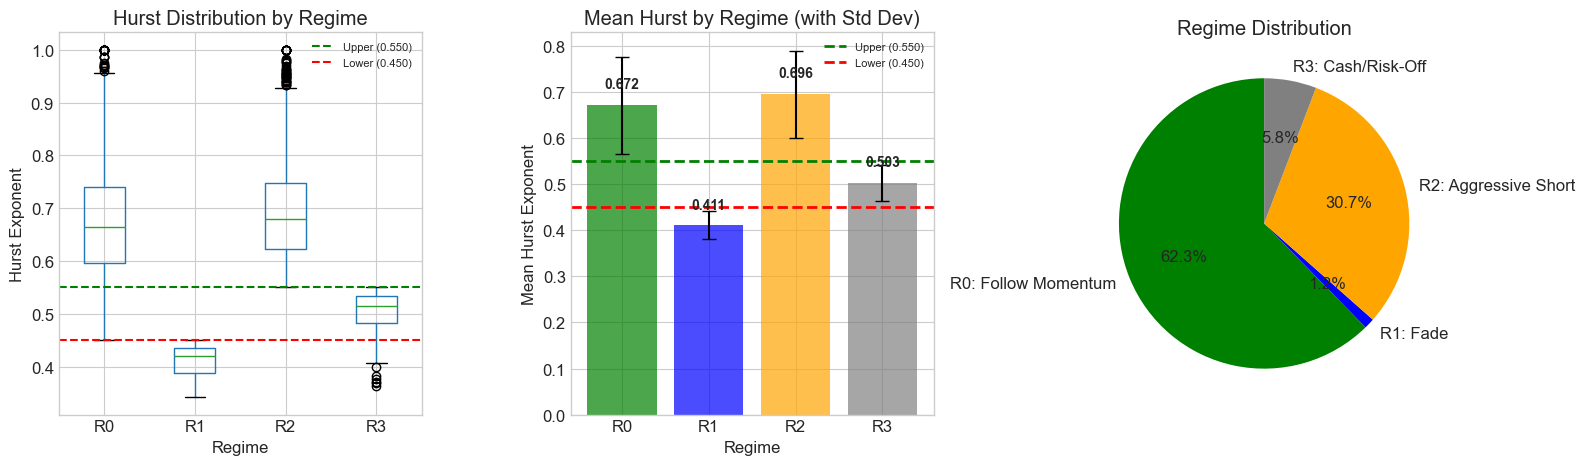

In [5]:
regime_labels = {
    0: 'Low Vol + Trending (Follow Momentum)',
    1: 'Low Vol + Mean-Rev (Fade)',
    2: 'High Vol + Trending (Aggressive Short)',
    3: 'High Vol + Random (Cash/Risk-Off)'
}

# Get regime statistics
regime_stats = regime_detector.get_regime_stats(regimes, hurst_values)

print("\n" + "="*70)
print("Mean Hurst Exponent by Regime")
print("="*70)

print(f"\n{'Regime':<50} {'Mean H':>8} {'Std':>8} {'Count':>8} {'%':>8}")
print("-"*82)
for regime in range(4):
    stats = regime_stats[regime]
    label = regime_labels.get(regime, f'Regime {regime}')
    if stats['count'] > 0:
        print(f"Regime {regime}: {label:<40} {stats['mean_hurst']:>8.3f} {stats['std_hurst']:>8.3f} {stats['count']:>8} {stats['pct']*100:>7.1f}%")
    else:
        print(f"Regime {regime}: {label:<40} {'N/A':>8} {'N/A':>8} {0:>8} {0:>7.1f}%")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Box plot of Hurst by regime
regime_hurst_df = pd.DataFrame({
    'regime': regimes,
    'hurst': hurst_values
}).dropna()
regime_hurst_df['regime_label'] = regime_hurst_df['regime'].map(lambda x: f"R{int(x)}")
regime_hurst_df.boxplot(column='hurst', by='regime_label', ax=axes[0])
axes[0].axhline(y=regime_detector.hurst_upper, color='green', linestyle='--', label=f'Upper ({regime_detector.hurst_upper:.3f})')
axes[0].axhline(y=regime_detector.hurst_lower, color='red', linestyle='--', label=f'Lower ({regime_detector.hurst_lower:.3f})')
axes[0].set_title('Hurst Distribution by Regime')
axes[0].set_xlabel('Regime')
axes[0].set_ylabel('Hurst Exponent')
axes[0].legend(fontsize=8)
plt.suptitle('')

# 2. Bar chart of mean Hurst with thresholds
colors = ['green', 'blue', 'orange', 'gray']
mean_hursts = [regime_stats[r]['mean_hurst'] if regime_stats[r]['count'] > 0 else 0 for r in range(4)]
std_hursts = [regime_stats[r]['std_hurst'] if regime_stats[r]['count'] > 0 else 0 for r in range(4)]
bars = axes[1].bar([f"R{i}" for i in range(4)], mean_hursts, 
                   yerr=std_hursts, capsize=5, color=colors, alpha=0.7)
axes[1].axhline(y=regime_detector.hurst_upper, color='green', linestyle='--', linewidth=2, label=f'Upper ({regime_detector.hurst_upper:.3f})')
axes[1].axhline(y=regime_detector.hurst_lower, color='red', linestyle='--', linewidth=2, label=f'Lower ({regime_detector.hurst_lower:.3f})')
axes[1].set_title('Mean Hurst by Regime (with Std Dev)')
axes[1].set_xlabel('Regime')
axes[1].set_ylabel('Mean Hurst Exponent')
axes[1].legend(fontsize=8)

for bar, val in zip(bars, mean_hursts):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Regime distribution pie chart
counts = [regime_stats[r]['count'] for r in range(4)]
labels_pie = [f"R{r}: {regime_labels[r].split('(')[1].replace(')', '')}" for r in range(4)]
non_zero = [(l, c, co) for l, c, co in zip(labels_pie, counts, colors) if c > 0]
if non_zero:
    axes[2].pie([x[1] for x in non_zero], labels=[x[0] for x in non_zero], 
                colors=[x[2] for x in non_zero], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Regime Distribution')

plt.tight_layout()
plt.show()

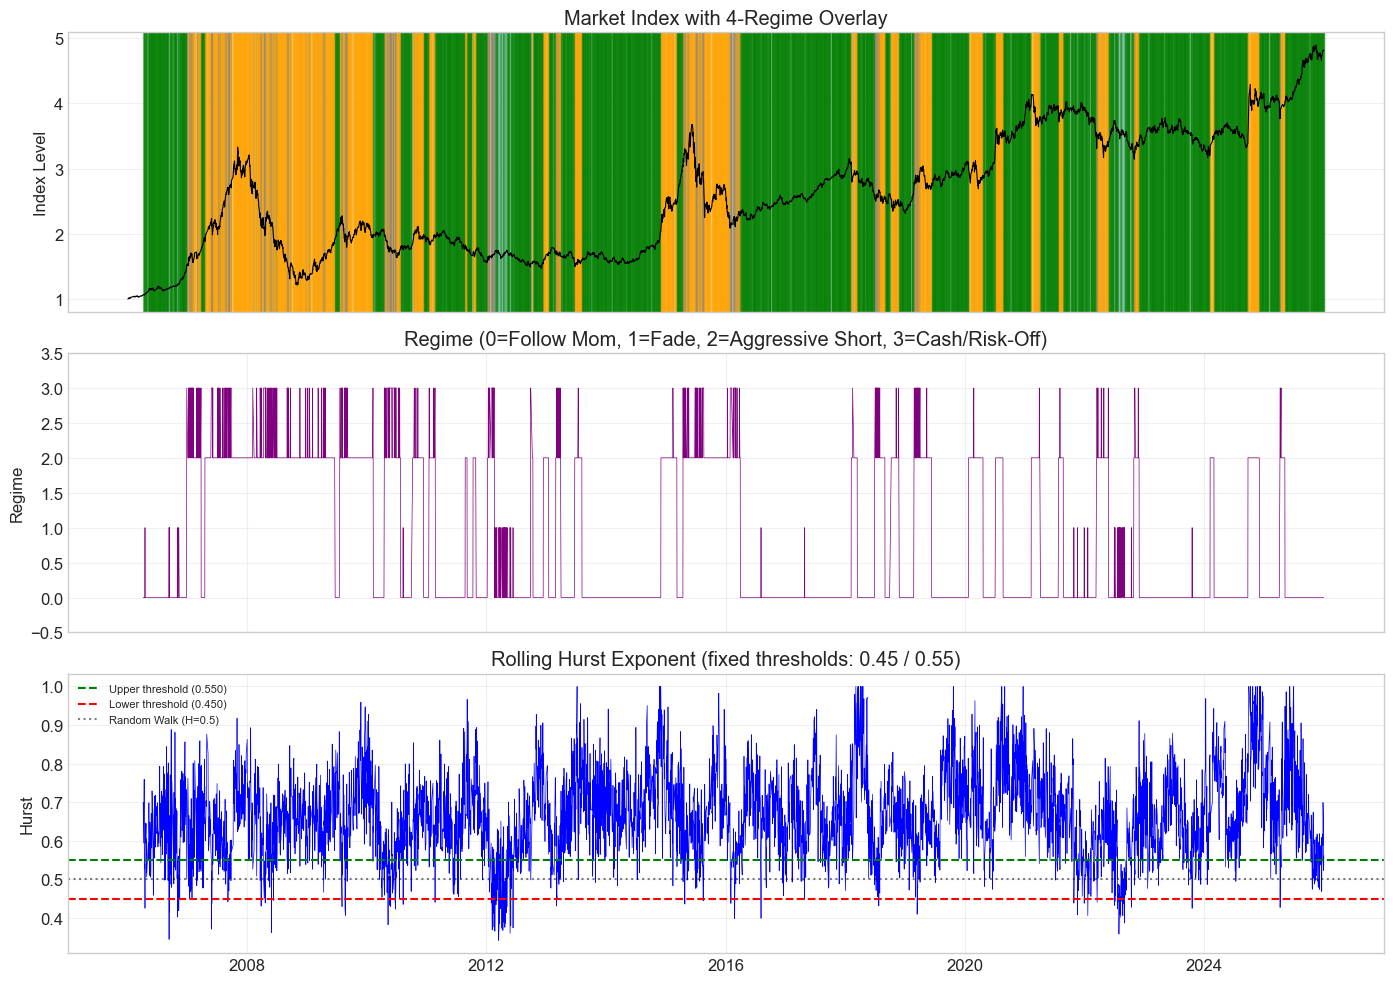

In [6]:
# Visualize 4-regime system
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot index with 4-regime coloring
axes[0].plot(index_level, color='black', linewidth=0.8, label='Index')
regime_colors = {0: 'green', 1: 'lightblue', 2: 'orange', 3: 'gray'}
regime_names = {0: 'Low Vol+Trend', 1: 'Low Vol+MR', 2: 'High Vol+Trend', 3: 'High Vol+Random'}
for i in range(len(regimes)-1):
    if pd.notna(regimes.iloc[i]):
        color = regime_colors.get(int(regimes.iloc[i]), 'gray')
        axes[0].axvspan(regimes.index[i], regimes.index[i+1], alpha=0.3, color=color)
axes[0].set_title('Market Index with 4-Regime Overlay')
axes[0].set_ylabel('Index Level')
axes[0].grid(True, alpha=0.3)

# Plot regime indicator
axes[1].plot(regimes, color='purple', linewidth=0.5)
axes[1].set_title('Regime (0=Follow Mom, 1=Fade, 2=Aggressive Short, 3=Cash/Risk-Off)')
axes[1].set_ylabel('Regime')
axes[1].set_ylim(-0.5, 3.5)
axes[1].grid(True, alpha=0.3)

# Plot Hurst exponent with fixed thresholds
axes[2].plot(hurst_values, color='blue', linewidth=0.5)
axes[2].axhline(y=regime_detector.hurst_upper, color='green', linestyle='--', 
                label=f'Upper threshold ({regime_detector.hurst_upper:.3f})')
axes[2].axhline(y=regime_detector.hurst_lower, color='red', linestyle='--', 
                label=f'Lower threshold ({regime_detector.hurst_lower:.3f})')
axes[2].axhline(y=0.5, color='black', linestyle=':', alpha=0.5, label='Random Walk (H=0.5)')
axes[2].set_title('Rolling Hurst Exponent (fixed thresholds: 0.45 / 0.55)')
axes[2].set_ylabel('Hurst')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Momentum Indicators for Entry/Exit Signals

We use multiple momentum indicators:
- **RSI**: Relative Strength Index (overbought/oversold)
- **MACD**: Moving Average Convergence Divergence
- **Moving Average Crossover**: Short-term vs long-term trend

In [7]:
# Calculate momentum indicators
mom = MomentumIndicators()
rsi = mom.rsi(index_level, period=14)
macd_line, signal_line, macd_hist = mom.macd(index_level)
ma_signal, short_ma, long_ma = mom.moving_average_crossover(index_level)

print("Momentum Indicators Calculated:")
print(f"  RSI range: {rsi.min():.1f} to {rsi.max():.1f}")
print(f"  MA Signal (bullish days): {(ma_signal == 1).sum()} ({(ma_signal == 1).mean():.1%})")

Momentum Indicators Calculated:
  RSI range: 6.6 to 99.2
  MA Signal (bullish days): 2686 (55.3%)


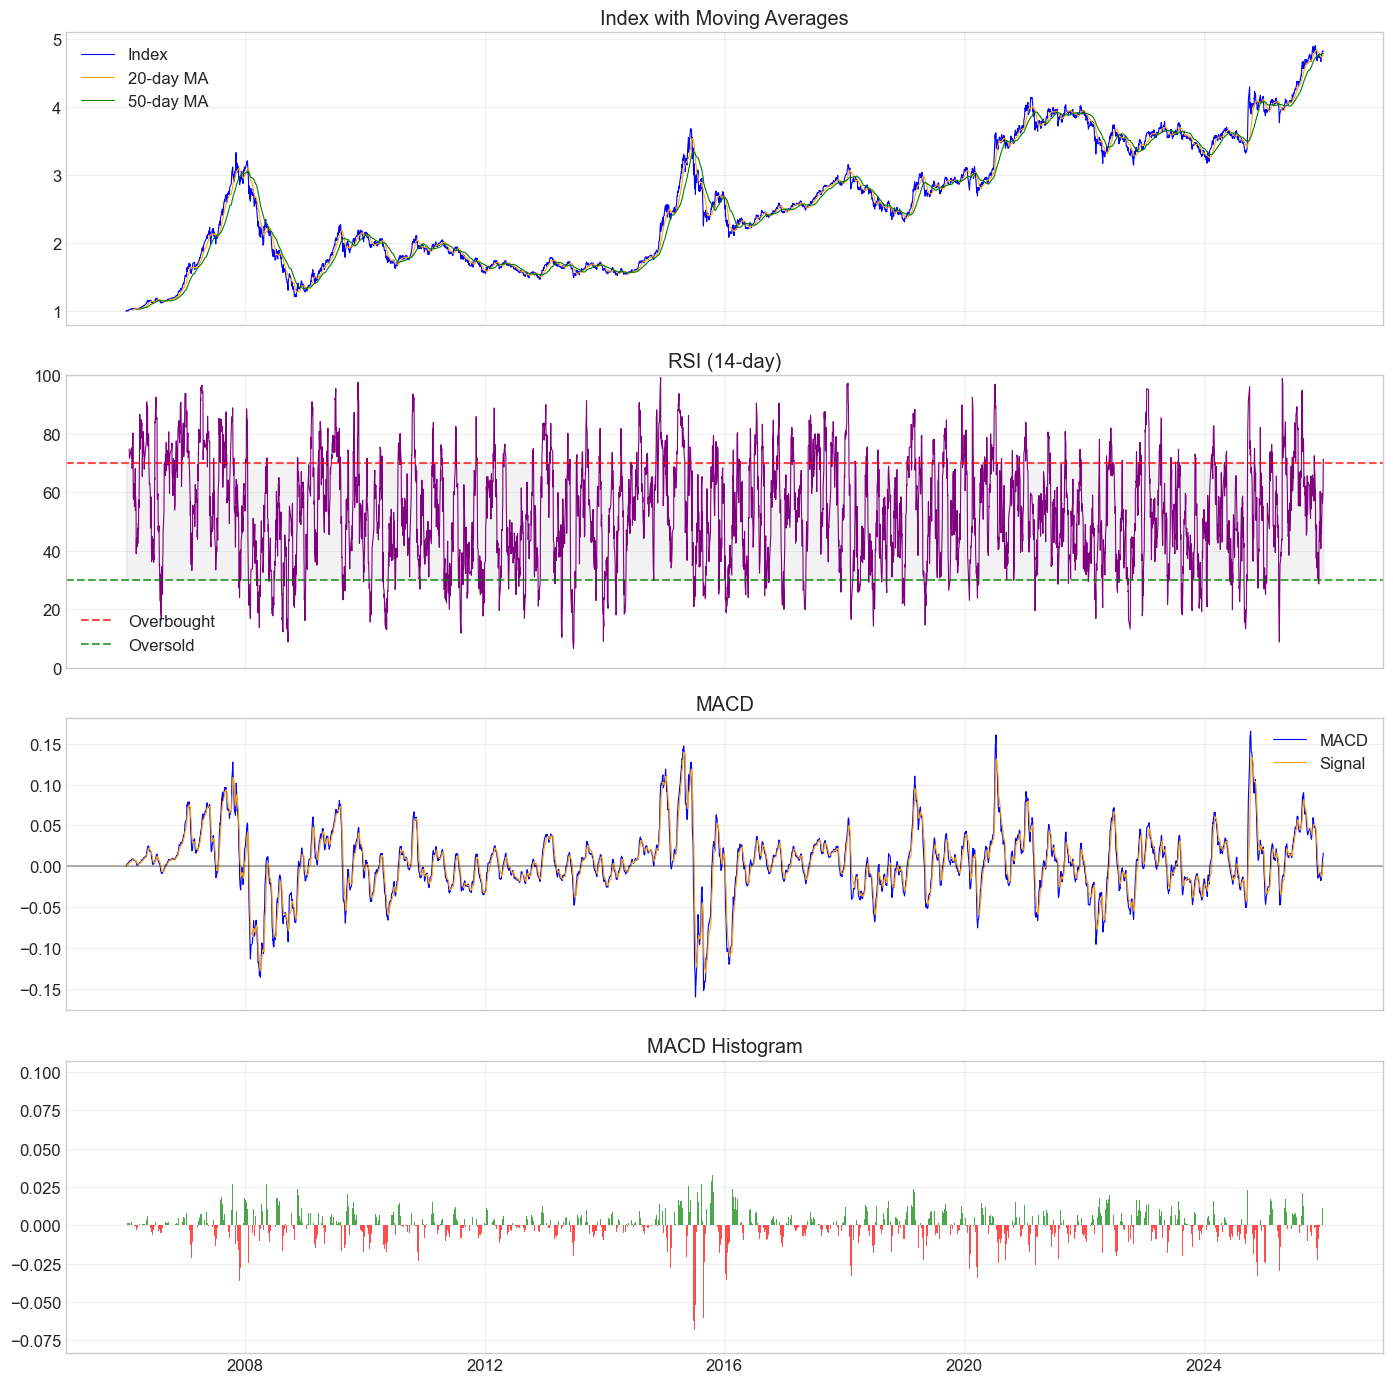

In [8]:
# Visualize momentum indicators
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Price with MAs
axes[0].plot(index_level, color='blue', linewidth=0.8, label='Index')
axes[0].plot(short_ma, color='orange', linewidth=0.8, label='20-day MA')
axes[0].plot(long_ma, color='green', linewidth=0.8, label='50-day MA')
axes[0].set_title('Index with Moving Averages')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(rsi, color='purple', linewidth=0.8)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold')
axes[1].fill_between(rsi.index, 30, 70, alpha=0.1, color='gray')
axes[1].set_title('RSI (14-day)')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(macd_line, color='blue', linewidth=0.8, label='MACD')
axes[2].plot(signal_line, color='orange', linewidth=0.8, label='Signal')
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].set_title('MACD')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# MACD Histogram
colors = ['green' if x > 0 else 'red' for x in macd_hist.values]
axes[3].bar(macd_hist.index, macd_hist.values, color=colors, width=1, alpha=0.7)
axes[3].set_title('MACD Histogram')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Adaptive Trading Strategy

The strategy adapts based on the integrated HMM-Hurst regime:
- **Regime 0 (Low Vol + Trending)**: Follow momentum - 100-120% position
- **Regime 1 (Low Vol + Mean-Rev)**: Fade / mean reversion - 85-105% position
- **Regime 2 (High Vol + Trending)**: Asymmetric response - 25-85% position
- **Regime 3 (High Vol + Random)**: Cash / risk-off - 25-60% position

**Key Design Principles:**
- 2-state HMM separates volatility regimes (Low Vol vs High Vol)
- Fixed Hurst thresholds (0.45 / 0.55) classify market behavior per architecture
- Low Vol regimes allow higher exposure; High Vol regimes trigger defensive positioning

In [9]:
# Run the adaptive trading strategy with optimized parameters
strategy = AdaptiveTradingStrategy(
    regime_lookback=252,
    hurst_window=60,
    position_size_base=1.0,
    trend_following_bias=True
)

# Generate signals using the index
signals = strategy.generate_signals(index_level, index_returns)

print("Strategy Signal Distribution:")
print(f"  Total signals: {len(signals)}")
print(f"  Position size range: {signals['position_size'].min():.2f} to {signals['position_size'].max():.2f}")
print(f"\nRegime Distribution in Signals:")
for r in range(4):
    count = (signals['regime'] == r).sum()
    pct = count / len(signals) * 100
    print(f"  Regime {r}: {count} days ({pct:.1f}%)")

Strategy Signal Distribution:
  Total signals: 4859
  Position size range: 0.31 to 1.14

Regime Distribution in Signals:
  Regime 0: 2990 days (61.5%)
  Regime 1: 56 days (1.2%)
  Regime 2: 1474 days (30.3%)
  Regime 3: 279 days (5.7%)


In [10]:
# Run backtest
results = run_backtest(index_level, signals)

# Print comprehensive results
print_backtest_results(results)

# Run backtest with transaction_cost
results = run_backtest(index_level, signals, transaction_cost=0.001)

# Print results
print_backtest_results(results)

BACKTEST RESULTS
Total Return:     458.68%
Annual Return:    9.33%
Volatility:       16.03%
Sharpe Ratio:     0.58
Max Drawdown:     -44.58%
Win Rate:         53.36%
Calmar Ratio:     0.21
BACKTEST RESULTS
Total Return:     458.68%
Annual Return:    9.33%
Volatility:       16.03%
Sharpe Ratio:     0.58
Max Drawdown:     -44.58%
Win Rate:         53.36%
Calmar Ratio:     0.21


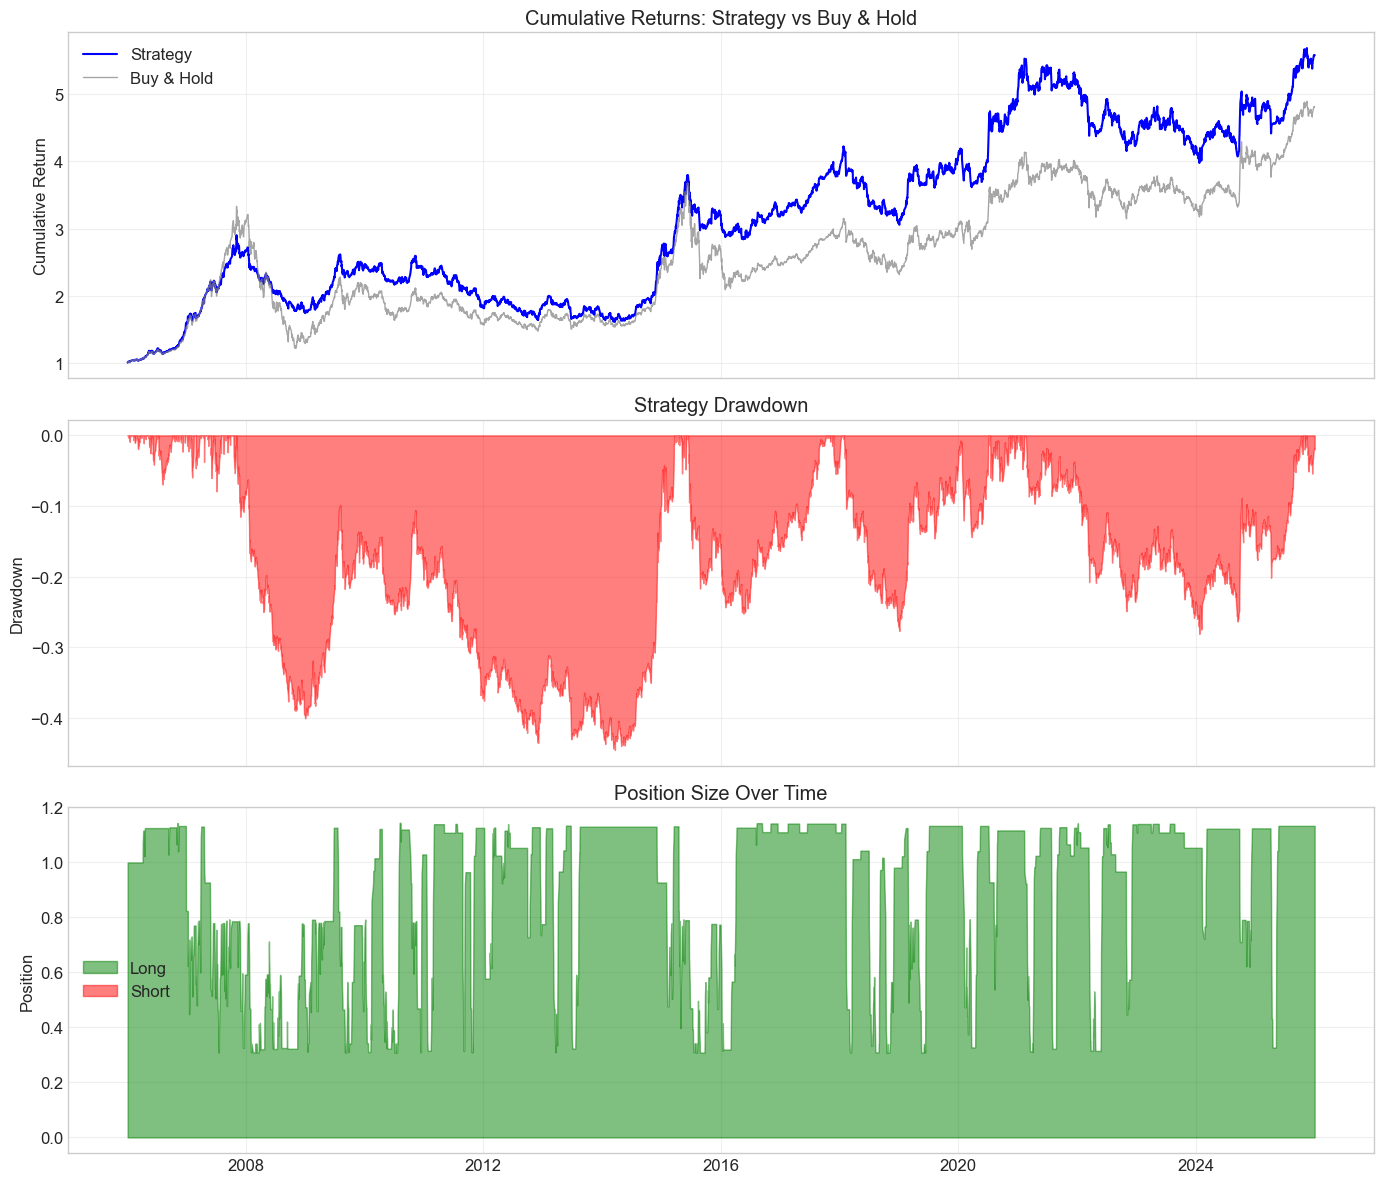

In [11]:
# Visualize backtest results
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Cumulative returns comparison
bh_returns = (1 + index_returns).cumprod()
bh_returns.iloc[0] = 1

axes[0].plot(results['cumulative_returns'], color='blue', linewidth=1.5, label='Strategy')
axes[0].plot(bh_returns, color='gray', linewidth=1, alpha=0.7, label='Buy & Hold')
axes[0].set_title('Cumulative Returns: Strategy vs Buy & Hold')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
rolling_max = results['cumulative_returns'].cummax()
drawdown = (results['cumulative_returns'] - rolling_max) / rolling_max
axes[1].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.5)
axes[1].set_title('Strategy Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)

# Position over time
position = results['positions']
axes[2].fill_between(position.index, position.values, 0, 
                     where=position > 0, color='green', alpha=0.5, label='Long')
axes[2].fill_between(position.index, position.values, 0, 
                     where=position < 0, color='red', alpha=0.5, label='Short')
axes[2].set_title('Position Size Over Time')
axes[2].set_ylabel('Position')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Regime Analysis

Market Returns by Regime:
          mean     std  count  annualized_return  annualized_vol  sharpe
regime                                                                  
0.0     0.0004  0.0081   2990             0.1128          0.1289  0.8752
1.0    -0.0013  0.0069     56            -0.3178          0.1093 -2.9088
2.0     0.0004  0.0189   1474             0.1116          0.2999  0.3723
3.0     0.0001  0.0208    279             0.0127          0.3301  0.0384


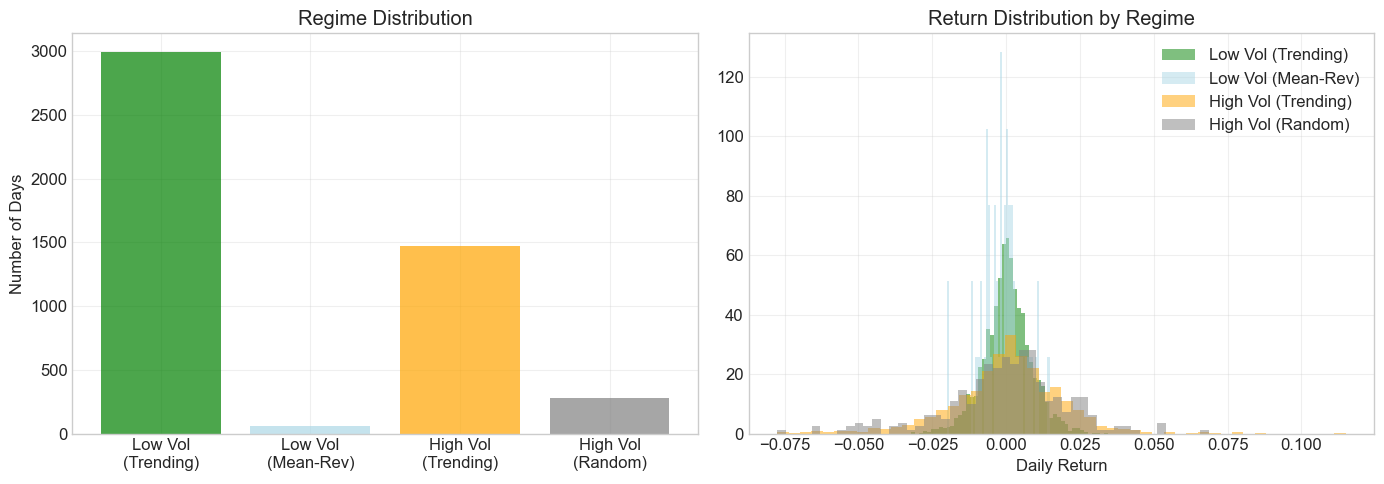

In [12]:
# Analyze returns by regime
regime_returns = pd.DataFrame({'returns': index_returns, 'regime': regimes})
regime_stats = regime_returns.groupby('regime')['returns'].agg(['mean', 'std', 'count'])
regime_stats['annualized_return'] = regime_stats['mean'] * 252
regime_stats['annualized_vol'] = regime_stats['std'] * np.sqrt(252)
regime_stats['sharpe'] = regime_stats['annualized_return'] / regime_stats['annualized_vol']

print("Market Returns by Regime:")
print(regime_stats.round(4))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime distribution - dynamically handle number of regimes
regime_counts = regimes.value_counts().sort_index()
n_regimes = len(regime_counts)

# Define labels and colors for 4 regimes (matching new naming convention)
regime_labels = ['Low Vol\n(Trending)', 'Low Vol\n(Mean-Rev)', 'High Vol\n(Trending)', 'High Vol\n(Random)'][:n_regimes]
regime_colors = ['green', 'lightblue', 'orange', 'gray'][:n_regimes]

axes[0].bar(regime_labels, regime_counts.values, color=regime_colors, alpha=0.7)
axes[0].set_title('Regime Distribution')
axes[0].set_ylabel('Number of Days')
axes[0].grid(True, alpha=0.3)

# Returns distribution by regime - dynamically handle all regimes
for reg, color, label in zip(range(n_regimes), regime_colors, regime_labels):
    mask = regimes == reg
    if mask.sum() > 0:
        axes[1].hist(index_returns[mask].dropna(), bins=50, alpha=0.5, color=color, label=label.replace('\n', ' '), density=True)
axes[1].set_title('Return Distribution by Regime')
axes[1].set_xlabel('Daily Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Risk Analysis

Risk Metrics:
  95% VaR:  -0.0154 (-1.54%)
  95% CVaR: -0.0239 (-2.39%)
  99% VaR:  -0.0287 (-2.87%)
  99% CVaR: -0.0378 (-3.78%)


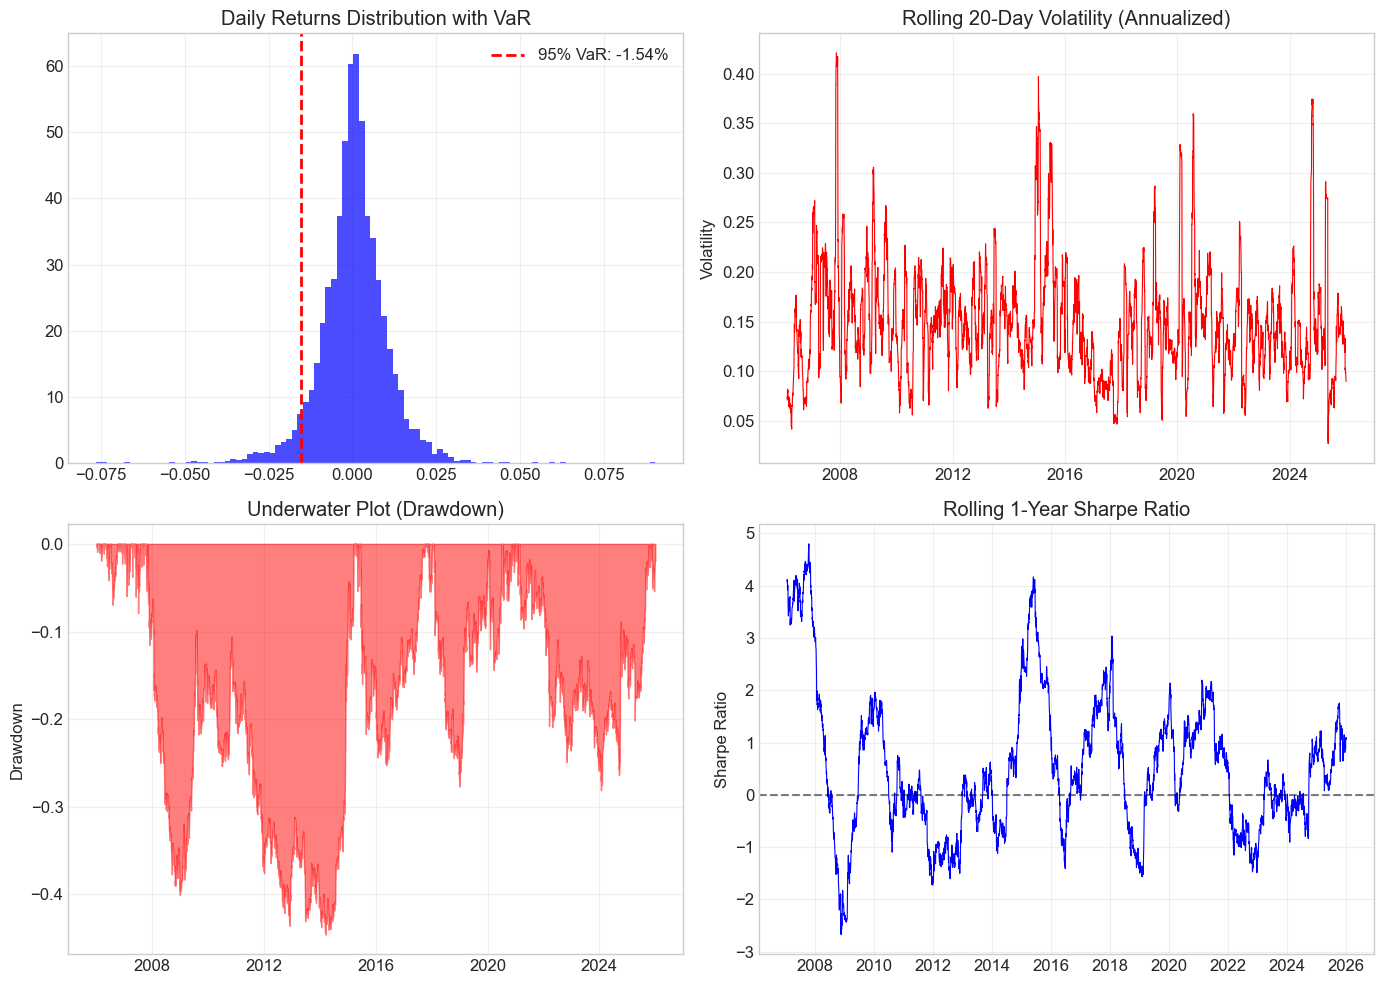

In [13]:
# Calculate VaR and CVaR
daily_returns = results['daily_returns'].dropna()

print("Risk Metrics:")
for conf in [0.95, 0.99]:
    var = np.percentile(daily_returns, (1-conf)*100)
    cvar = daily_returns[daily_returns <= var].mean()
    print(f"  {conf*100:.0f}% VaR:  {var:.4f} ({var*100:.2f}%)")
    print(f"  {conf*100:.0f}% CVaR: {cvar:.4f} ({cvar*100:.2f}%)")

# Visualize risk metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Return distribution with VaR
axes[0, 0].hist(daily_returns, bins=100, alpha=0.7, color='blue', density=True)
var_95 = np.percentile(daily_returns, 5)
axes[0, 0].axvline(x=var_95, color='red', linestyle='--', linewidth=2, label=f'95% VaR: {var_95:.2%}')
axes[0, 0].set_title('Daily Returns Distribution with VaR')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Rolling volatility
rolling_vol = daily_returns.rolling(20).std() * np.sqrt(252)
axes[0, 1].plot(rolling_vol, color='red', linewidth=0.8)
axes[0, 1].set_title('Rolling 20-Day Volatility (Annualized)')
axes[0, 1].set_ylabel('Volatility')
axes[0, 1].grid(True, alpha=0.3)

# Drawdown
axes[1, 0].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.5)
axes[1, 0].set_title('Underwater Plot (Drawdown)')
axes[1, 0].set_ylabel('Drawdown')
axes[1, 0].grid(True, alpha=0.3)

# Rolling Sharpe
rolling_sharpe = (daily_returns.rolling(252).mean() / daily_returns.rolling(252).std()) * np.sqrt(252)
axes[1, 1].plot(rolling_sharpe, color='blue', linewidth=0.8)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Rolling 1-Year Sharpe Ratio')
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Monthly Returns Heatmap

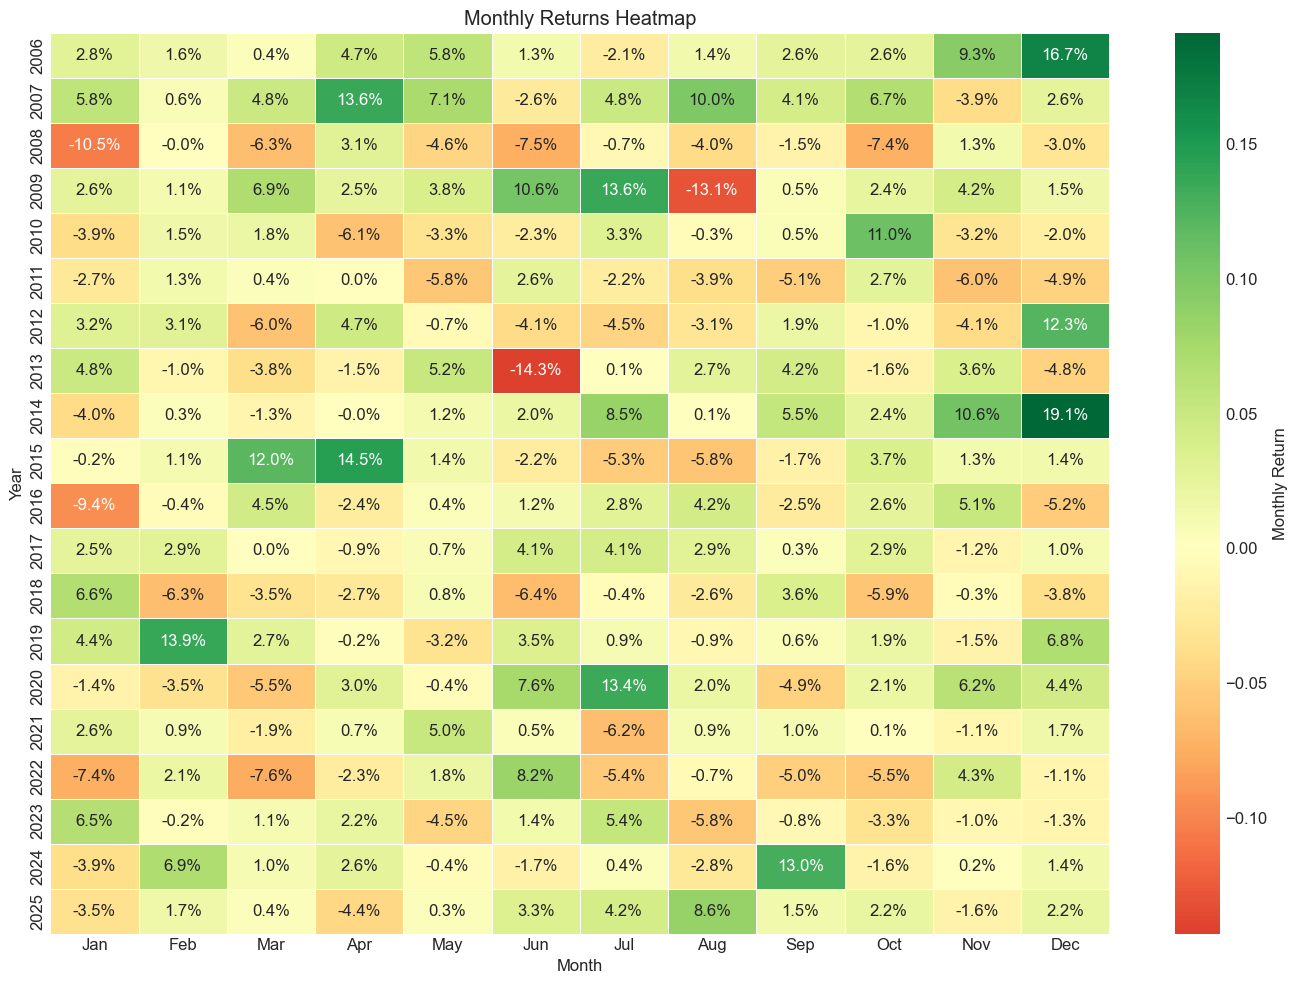

In [14]:
# Monthly returns heatmap
monthly_returns = results['daily_returns'].resample('ME').sum()
monthly_df = monthly_returns.to_frame('returns')
monthly_df['year'] = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month

pivot = monthly_df.pivot_table(values='returns', index='year', columns='month', aggfunc='sum')
pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0, 
            linewidths=0.5, cbar_kws={'label': 'Monthly Return'})
plt.title('Monthly Returns Heatmap')
plt.ylabel('Year')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

## 10. Performance Attribution Report

Performance attribution decomposes the active return (portfolio return - benchmark return) into components:

### Brinson-Hood-Beebower (BHB) Model
Decomposes active return into three effects:
- **Allocation Effect**: $(W_p - W_b) \times R_b$ - Impact of over/underweighting sectors
- **Selection Effect**: $W_b \times (R_p - R_b)$ - Impact of stock selection within sectors  
- **Interaction Effect**: $(W_p - W_b) \times (R_p - R_b)$ - Combined effect

**Note:** Since this strategy only tilts sector weights and does not select individual stocks within sectors, the Selection and Interaction effects are zero. All active return comes from the Allocation Effect.

Where:
- $W_p$, $W_b$ = Portfolio and Benchmark sector weights
- $R_p$, $R_b$ = Portfolio and Benchmark sector returns

Sector Distribution of Stocks:
  Industrials: 184 stocks (20.5%)
  Materials: 141 stocks (15.7%)
  Information Technology: 128 stocks (14.3%)
  Financials: 87 stocks (9.7%)
  Health Care: 70 stocks (7.8%)
  Consumer Discretionary: 66 stocks (7.4%)
  Real Estate: 50 stocks (5.6%)
  Consumer Staples: 50 stocks (5.6%)
  Utilities: 42 stocks (4.7%)
  Communication Services: 41 stocks (4.6%)
  Energy: 37 stocks (4.1%)

Total stocks with valid GICS codes: 896


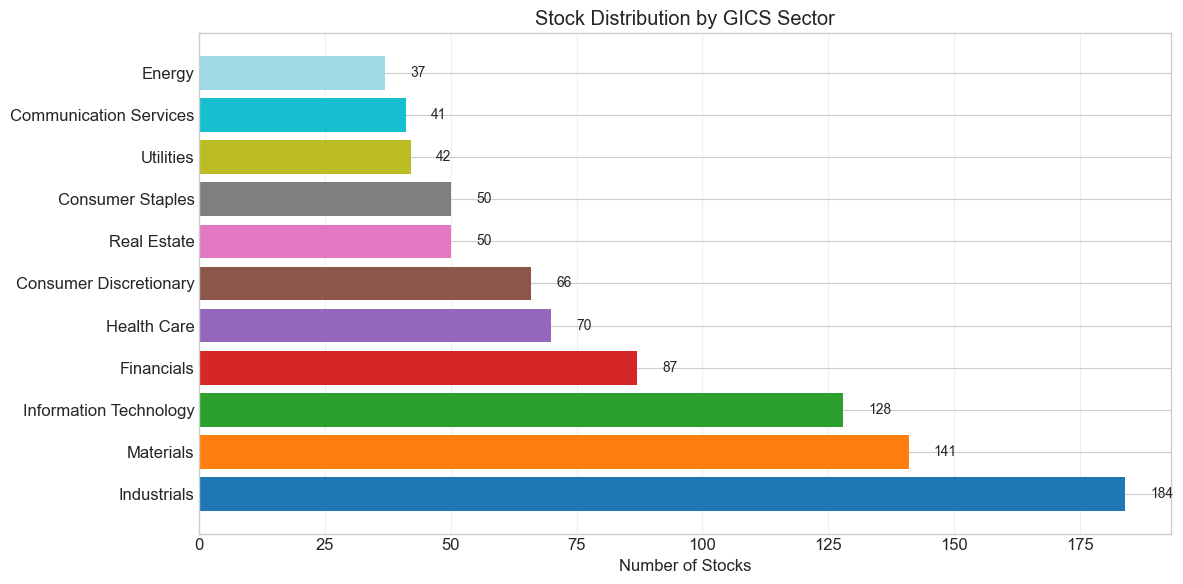

In [15]:
# Load sector mapping and display sector distribution
sector_mapping = load_sector_mapping('data_cn')

print("Sector Distribution of Stocks:")
print("="*50)
sector_counts = sector_mapping['sector'].value_counts()
for sector, count in sector_counts.items():
    print(f"  {sector}: {count} stocks ({count/len(sector_mapping)*100:.1f}%)")

print(f"\nTotal stocks with valid GICS codes: {len(sector_mapping)}")

# Visualize sector distribution
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(sector_counts)))
bars = ax.barh(sector_counts.index, sector_counts.values, color=colors)
ax.set_xlabel('Number of Stocks')
ax.set_title('Stock Distribution by GICS Sector')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, sector_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# Run Performance Attribution Analysis
print("Running Brinson Attribution Analysis...")
print("="*60)

attribution_results = run_sector_attribution(data, signals, 'data_cn')

# Display Summary
summary = attribution_results['summary']

print("\n" + "="*60)
print("PERFORMANCE ATTRIBUTION SUMMARY")
print("="*60)

print(f"\nAnalysis Period: {summary['n_years']:.1f} years")

print(f"\n{'':30s} {'Total':>12s} {'Annualized':>12s}")
print("-"*56)
print(f"{'Portfolio Return':30s} {summary['portfolio_total_return']:>11.2%} {summary['portfolio_annual_return']:>11.2%}")
print(f"{'Benchmark Return':30s} {summary['benchmark_total_return']:>11.2%} {summary['benchmark_annual_return']:>11.2%}")
print(f"{'Active Return':30s} {summary['active_return']:>11.2%} {summary['portfolio_annual_return'] - summary['benchmark_annual_return']:>11.2%}")

print("\n" + "-"*60)
print("Brinson-Hood-Beebower (BHB) Decomposition (annualized):")
print("-"*60)
print(f"  Allocation Effect:   {summary['bhb']['Total Allocation']:.4%}")
print(f"  Selection Effect:    {summary['bhb']['Total Selection']:.4%}")
print(f"  Interaction Effect:  {summary['bhb']['Total Interaction']:.4%}")
print(f"  Total Active Return: {summary['bhb']['Total Active Return']:.4%}")

print("\n" + "="*60)

Running Brinson Attribution Analysis...

PERFORMANCE ATTRIBUTION SUMMARY

Analysis Period: 19.3 years

                                      Total   Annualized
--------------------------------------------------------
Portfolio Return                  2895.00%      19.28%
Benchmark Return                  2752.39%      18.98%
Active Return                      142.61%       0.30%

------------------------------------------------------------
Brinson-Hood-Beebower (BHB) Decomposition (annualized):
------------------------------------------------------------
  Allocation Effect:   0.2815%
  Selection Effect:    0.0000%
  Interaction Effect:  -0.0000%
  Total Active Return: 0.2815%



Sector Tilts by Regime (Overweight/Underweight)

Sector Tilts (% deviation from neutral weight):
--------------------------------------------------------------------------------
Utilities                 | R0:  -30.0% | R1:  +10.0% | R2:   +0.0% | R3:  +30.0%
Consumer Staples          | R0:  -20.0% | R1:   +5.0% | R2:   +0.0% | R3:  +20.0%
Health Care               | R0:   +0.0% | R1:   +0.0% | R2:   +5.0% | R3:  +10.0%
Financials                | R0:  +10.0% | R1:   +0.0% | R2:   +0.0% | R3:  -20.0%
Information Technology    | R0:  +40.0% | R1:   -5.0% | R2:  +10.0% | R3:  -30.0%
Consumer Discretionary    | R0:  +30.0% | R1:   +0.0% | R2:   +5.0% | R3:  -20.0%
Industrials               | R0:  +20.0% | R1:   +0.0% | R2:   +5.0% | R3:  -10.0%
Materials                 | R0:  +15.0% | R1:   +5.0% | R2:   +0.0% | R3:  -15.0%
Real Estate               | R0:  -10.0% | R1:  +10.0% | R2:   -5.0% | R3:  -10.0%
Communication Services    | R0:  +10.0% | R1:   +0.0% | R2:   +0.0% | R3:   -5.0%
En

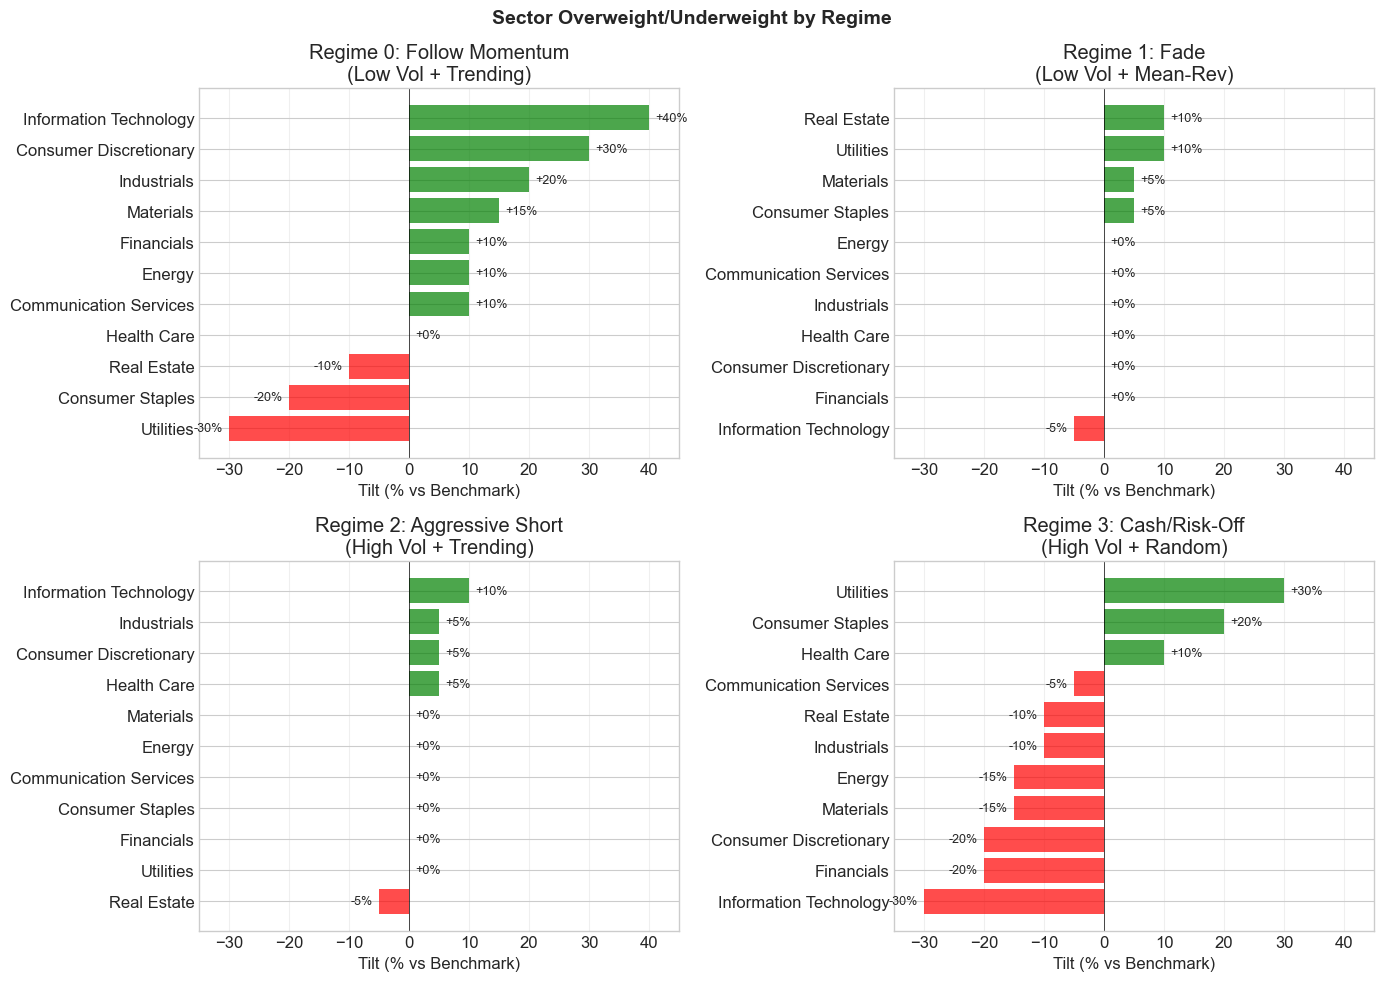


REGIME-BASED SECTOR ALLOCATION STRATEGY

Regime 0 (Follow Momentum - Low Vol + Trending):
   Overweight: IT (+40%), Consumer Disc (+30%), Industrials (+20%)
   Underweight: Utilities (-30%), Consumer Staples (-20%)
   -> Aggressive growth/momentum in favorable trending markets

Regime 1 (Fade - Low Vol + Mean-Reverting):
   Overweight: Real Estate (+10%), Utilities (+10%), Materials (+5%)
   Underweight: IT (-5%)
   -> Value/yield focus in calm, range-bound markets

Regime 2 (Aggressive Short - High Vol + Trending):
   Slight overweight: IT (+10%), Consumer Disc (+5%), Industrials (+5%)
   Slight underweight: Real Estate (-5%)
   -> Cautious momentum tilt despite high volatility

Regime 3 (Cash/Risk-Off - High Vol + Random):
   Overweight: Utilities (+30%), Consumer Staples (+20%), Health Care (+10%)
   Underweight: IT (-30%), Consumer Disc (-20%), Financials (-20%)
   -> Defensive positioning during volatile, erratic markets


In [17]:
# Display Sector Overweight/Underweight by Regime
print("Sector Tilts by Regime (Overweight/Underweight)")
print("="*80)

# Get the sector regime tilts
sector_tilts = get_sector_regime_tilts()

# Create a DataFrame for display
regime_names = {
    0: 'Regime 0: Follow Momentum\n(Low Vol + Trending)',
    1: 'Regime 1: Fade\n(Low Vol + Mean-Rev)',
    2: 'Regime 2: Aggressive Short\n(High Vol + Trending)',
    3: 'Regime 3: Cash/Risk-Off\n(High Vol + Random)'
}

# Get all sectors
all_sectors = list(sector_tilts[0].keys())
all_sectors = [s for s in all_sectors if s != 'Other']  # Exclude 'Other'

# Create tilt DataFrame
tilt_df = pd.DataFrame(index=all_sectors)
for regime in range(4):
    tilt_df[f'Regime {regime}'] = [sector_tilts[regime].get(s, 1.0) for s in all_sectors]

# Convert to percentage deviation from neutral (1.0)
tilt_pct = (tilt_df - 1.0) * 100

print("\nSector Tilts (% deviation from neutral weight):")
print("-"*80)
for sector in all_sectors:
    row = tilt_pct.loc[sector]
    print(f"{sector:25s} | R0: {row['Regime 0']:+6.1f}% | R1: {row['Regime 1']:+6.1f}% | R2: {row['Regime 2']:+6.1f}% | R3: {row['Regime 3']:+6.1f}%")

# Visualize sector tilts by regime
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, regime in enumerate(range(4)):
    ax = axes[idx // 2, idx % 2]
    tilts = tilt_pct[f'Regime {regime}'].sort_values(ascending=True)
    colors = ['green' if x > 0 else 'red' for x in tilts.values]
    
    ax.barh(tilts.index, tilts.values, color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Tilt (% vs Benchmark)')
    ax.set_title(regime_names[regime])
    ax.set_xlim(-35, 45)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (sector, val) in enumerate(tilts.items()):
        ax.text(val + 1 if val >= 0 else val - 1, i, f'{val:+.0f}%', 
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Sector Overweight/Underweight by Regime', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary interpretation
print("\n" + "="*80)
print("REGIME-BASED SECTOR ALLOCATION STRATEGY")
print("="*80)

print("\nRegime 0 (Follow Momentum - Low Vol + Trending):")
print("   Overweight: IT (+40%), Consumer Disc (+30%), Industrials (+20%)")
print("   Underweight: Utilities (-30%), Consumer Staples (-20%)")
print("   -> Aggressive growth/momentum in favorable trending markets")

print("\nRegime 1 (Fade - Low Vol + Mean-Reverting):")
print("   Overweight: Real Estate (+10%), Utilities (+10%), Materials (+5%)")
print("   Underweight: IT (-5%)")
print("   -> Value/yield focus in calm, range-bound markets")

print("\nRegime 2 (Aggressive Short - High Vol + Trending):")
print("   Slight overweight: IT (+10%), Consumer Disc (+5%), Industrials (+5%)")
print("   Slight underweight: Real Estate (-5%)")
print("   -> Cautious momentum tilt despite high volatility")

print("\nRegime 3 (Cash/Risk-Off - High Vol + Random):")
print("   Overweight: Utilities (+30%), Consumer Staples (+20%), Health Care (+10%)")
print("   Underweight: IT (-30%), Consumer Disc (-20%), Financials (-20%)")
print("   -> Defensive positioning during volatile, erratic markets")

## 10. Conclusion

This notebook implements a medium-term trading strategy that:

1. **Detects market regimes** using Hidden Markov Models (HMM)
   - Identifies Low Vol (Risk-On) and High Vol (Risk-Off) periods
   - Reduces exposure during high volatility regimes

2. **Classifies market behavior** using the Hurst exponent
   - H < 0.5: Mean-reverting (use contrarian strategies)
   - H > 0.5: Trending (use momentum strategies)
   - H ≈ 0.5: Random walk (reduce exposure)

3. **Generates adaptive signals** using momentum indicators
   - RSI for overbought/oversold conditions
   - MACD for trend confirmation
   - Moving average crossovers for trend direction

4. **Sizes positions dynamically** based on:
   - Current regime (reduce in high vol)
   - Inverse volatility targeting

In [18]:
# Final Summary
print("="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)

# Strategy metrics
print(f"\nStrategy Performance:")
print(f"  Total Return:     {results['total_return']:.2%}")
print(f"  Annual Return:    {results['annual_return']:.2%}")
print(f"  Volatility:       {results['volatility']:.2%}")
print(f"  Sharpe Ratio:     {results['sharpe_ratio']:.2f}")
print(f"  Max Drawdown:     {results['max_drawdown']:.2%}")
print(f"  Win Rate:         {results['win_rate']:.2%}")
print(f"  Calmar Ratio:     {results['calmar_ratio']:.2f}")

# Buy & Hold comparison
bh_total = bh_returns.iloc[-1] - 1
bh_annual = (1 + bh_total) ** (252 / len(bh_returns)) - 1
bh_vol = index_returns.std() * np.sqrt(252)
bh_sharpe = bh_annual / bh_vol

print(f"\nBuy & Hold Benchmark:")
print(f"  Total Return:     {bh_total:.2%}")
print(f"  Annual Return:    {bh_annual:.2%}")
print(f"  Volatility:       {bh_vol:.2%}")
print(f"  Sharpe Ratio:     {bh_sharpe:.2f}")

print("\n" + "="*60)

FINAL PERFORMANCE SUMMARY

Strategy Performance:
  Total Return:     458.68%
  Annual Return:    9.33%
  Volatility:       16.03%
  Sharpe Ratio:     0.58
  Max Drawdown:     -44.58%
  Win Rate:         53.36%
  Calmar Ratio:     0.21

Buy & Hold Benchmark:
  Total Return:     381.79%
  Annual Return:    8.50%
  Volatility:       20.96%
  Sharpe Ratio:     0.41

